Sequence shape: (1083, 14, 13)
Total images: 544
Image shape: (544, 128, 128, 3)
Matched samples: 537
Seq flattened: (537, 182)
Img flattened: (537, 49152)
Compressed image shape: (537, 100)
Final feature shape: (537, 282)
MAE: 136.57285259388112
RMSE: 160.4184131672205
R2: -0.19039795891799138
Model Accuracy: 19.444444444444446 %


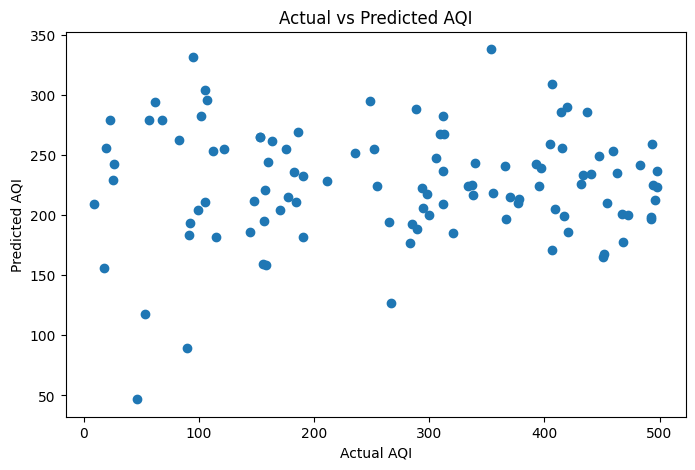

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from xgboost import XGBRegressor

# =========================
# LOAD SEQUENCE DATA
# =========================
X_seq = np.load("../data/X_sequences.npy")
y = np.load("../data/y_targets.npy")
dates = pd.read_csv("../data/sequence_dates.csv")

dates['Date'] = pd.to_datetime(dates['Date'])

print("Sequence shape:", X_seq.shape)

# =========================
# LOAD SATELLITE IMAGES
# =========================
base_folder = "../satellite images"

image_paths = []

for root, dirs, files in os.walk(base_folder):
    for file in files:
        if file.endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(root, file))

print("Total images:", len(image_paths))

IMG_SIZE = (128, 128)

processed_images = []
image_dates = []

for path in image_paths:
    img = Image.open(path).convert("RGB")
    img = img.resize(IMG_SIZE)
    img = np.array(img) / 255.0

    processed_images.append(img)

    filename = os.path.basename(path)
    date_part = filename.split(".")[0]
    image_dates.append(pd.to_datetime(date_part))

processed_images = np.array(processed_images)

print("Image shape:", processed_images.shape)

# =========================
# MATCH DATES
# =========================
image_df = pd.DataFrame({
    'Date': image_dates
})

matched_dates = pd.merge(dates, image_df, on='Date', how='inner')

date_to_seq = {d: i for i, d in enumerate(dates['Date'])}
date_to_img = {d: i for i, d in enumerate(image_dates)}

matched_seq = []
matched_img = []
matched_targets = []

for d in matched_dates['Date']:
    matched_seq.append(X_seq[date_to_seq[d]])
    matched_img.append(processed_images[date_to_img[d]])
    matched_targets.append(y[date_to_seq[d]])

matched_seq = np.array(matched_seq)
matched_img = np.array(matched_img)
matched_targets = np.array(matched_targets)

print("Matched samples:", matched_seq.shape[0])

# =========================
# FLATTEN FEATURES
# =========================
seq_features = matched_seq.reshape(matched_seq.shape[0], -1)
img_features = matched_img.reshape(matched_img.shape[0], -1)

print("Seq flattened:", seq_features.shape)
print("Img flattened:", img_features.shape)

# =========================
# PCA IMAGE COMPRESSION
# =========================
pca = PCA(n_components=100)

img_features_pca = pca.fit_transform(img_features)

print("Compressed image shape:", img_features_pca.shape)

# =========================
# COMBINE FEATURES
# =========================
X_final = np.concatenate([seq_features, img_features_pca], axis=1)

print("Final feature shape:", X_final.shape)

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_final,
    matched_targets,
    test_size=0.2,
    random_state=42
)

# =========================
# XGBOOST MODEL
# =========================
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

# =========================
# PREDICT
# =========================
pred = model.predict(X_test)

# =========================
# METRICS
# =========================
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

# =========================
# TOLERANCE ACCURACY
# =========================
error = np.abs(y_test - pred)

correct = np.sum(error <= 50)

accuracy = (correct / len(error)) * 100

print("Model Accuracy:", accuracy, "%")

# =========================
# PLOT
# =========================
plt.figure(figsize=(8,5))

plt.scatter(y_test, pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI")

plt.show()